# Машинное обучение с подкреплением.
## Семинар 1
### Обучение с подкреплением: OpenAI gym, CrossEntropy Method (CEM), Deep CEM.

## Deps

In [9]:
!pip install gym==0.22.0

Импортируем необходимые библиотеки и настраиваем визуализацию:

In [42]:
try:
    import colab
    COLAB = True
except ModuleNotFoundError:
    COLAB = False
    pass

if COLAB:
    !wget https://gist.githubusercontent.com/Tviskaron/4d35eabce2e057dd2ea49a00b00aaa41/raw/f1e25fc6ac6d8f11cb585559ce8b2ab9ffefd67b/colab_render.sh -O colab_render.sh -q
    !sh colab_render.sh
    !wget https://gist.githubusercontent.com/Tviskaron/d91decc1ca5f1b09af2f9f080011a925/raw/0d3474f65b4aea533996ee00edf99a37e4da5561/colab_render.py -O colab_render.py -q
    import colab_render

In [11]:
import glob
import io
import base64
from IPython import display as ipythondisplay
from IPython.display import HTML
import matplotlib.pyplot as plt
import gym

%matplotlib inline

def show_video(folder="./video"):
    mp4list = glob.glob(folder + '/*.mp4')
    if len(mp4list) > 0:
        mp4 = sorted(mp4list, key=lambda x: x[-15:], reverse=True)[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

# Тестируем рендер среды
env = gym.make("CartPole-v1")
env.reset()
env = gym.wrappers.RecordVideo(env, "./video")

for _ in range(100):
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    if done:
        break
env.close()
show_video()

/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:41: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## 1. OpenAI Gym

[Gym](https://gym.openai.com), [Gymnasium](https://gymnasium.farama.org/)$-$ это набор инструментов для разработки и сравнения алгоритмов обучения с подкреплением, который также включает в себя большой [набор окружений](https://gym.openai.com/envs/).

### Создание окружения

Для создания окружения используется функция ```gym.make(<имя окружения>)```.

In [12]:
import gym

# Создаем окружение
env = gym.make("MountainCar-v0")

# Инициализируем окружение
state = env.reset()
print(f"state: {state}")

# Выполняем действие в среде
next_state, r, done, info = env.step(0)
print(f"next_state: {next_state} , r: {r}, done: {done}, info: {info}")

# Закрываем окружение
env.close()

state: [-0.5667205  0.       ]
next_state: [-0.56739795 -0.00067749] , r: -1.0, done: False, info: {}


### Основные методы окружения:

* ``reset()`` $-$ инициализация окружения, возвращает первое наблюдение (состояние).  
* ``step(a)`` $-$ выполнить в среде действие $\mathbf{a}$ и получить кортеж: $\mathbf{\langle s_{t+1}, r_t, done, info \rangle}$, где $\mathbf{s_{t+1}}$ - следующее состояние, $\mathbf{r_t}$ - вознаграждение, $\mathbf{done}$ - флаг заверешния, $\mathbf{info}$ - дополнительная информация

### Дополнительные методы:
* ``render()`` $-$ визуализация текущего состояния среды (удобно, если мы запускаем локально, в колабе ничего не увидим)

* ``close()`` $-$ закрывает окружение

### Атрибуты среды:
* ``env.observation_space`` $-$ информация о пространстве состояний
* ``env.action_space`` $-$ информация о пространстве действий


In [13]:
print(f"env.observation_space: {env.observation_space}")
print(f"env.action_space: {env.action_space}")

env.observation_space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
env.action_space: Discrete(3)


### Среда ``MountainCar-v0``

Информацию о любой среде можно найти в https://www.gymlibrary.dev/environments/classic_control/mountain_car/. О ``MountainCar-v0`` мы можем узнать следующее:

#### Задание:
Автомобиль едет по одномерному треку между двумя холмами. Цель состоит в том, чтобы заехать на правый холм; однако двигатель машины недостаточно мощный, чтобы взобраться на холм за один проход. Следовательно, единственный способ добиться успеха $-$ это двигаться вперед и назад, чтобы набрать обороты.

#### Пространство состояний Box(2):



Num | Observation  | Min  | Max  
----|--------------|------|----   
0   | position     | -1.2 | 0.6
1   | velocity     | -0.07| 0.07


#### Пространство действий Discrete(3):



Num | Action|
----|-------------|
0   | push left   |
1   | no push     |
2   | push right  |

* Вознаграждения: -1 за каждый шаг, пока не достигнута цель

* Начальное состояние: Случайная позиция от -0.6 до -0.4 с нулевой скоростью.

### Пример со случайной стратегией:

Для выбора действия используется ``env.action_space.sample()``

In [14]:
# создаем окружение
env = gym.make("MountainCar-v0")
# добавляем wrapper (обертку), чтобы задать ограничение на число шагов в среде
env = gym.wrappers.TimeLimit(env, max_episode_steps=250)
# добавляем визуализацию
env = gym.wrappers.Monitor(env, "./video", force=True)

# проводим инициализацию и запоминаем начальное состояние
s = env.reset()
done = False

while not done:
    # выполняем действие, получаем state, reward, done, info
    action = env.action_space.sample()
    state, reward, done, _ = env.step(action)

env.close()

# Сначала закрываем окружение, чтобы видео записалось полностью
env.close()
show_video()

env.close()

### Задание 1:
В среде MountainCar-v0 мы хотим, чтобы машина достигла флага. Давайте решим эту задачу, не используя обучение с подкреплением. Модифицируйте код функции act() ниже для выполнения этого задания. Функция получает на вход состояние среды и должна вернуть действие.

In [15]:
def act(s):
    # список возможных действий
    left, stop, right = 0, 1, 2

    # позиция и скорость
    position, velocity = s

    # action =
    ####### Здесь ваш код ########
    #raise NotImplementedError
    action = 2 if velocity > 0 else 0
    ##############################

    return action

Проверяем решение:

In [16]:
env = gym.wrappers.TimeLimit(gym.make("MountainCar-v0"), max_episode_steps=250)
env = gym.wrappers.Monitor(env, "./video", force=True)

# проводим инициализацию и запоминаем начальное состояние
s = env.reset()
done = False

while not done:
    # выполняем действие, получаем s, r, done, info
    s, r, done, _ = env.step(act(s))

if s[0] > 0.47:
    print("Принято!")
else:
    print("""Исправьте функцию выбора действия!""")


env.close()
show_video()

env.close()

Принято!


## 2. Crossentropy Method

В этой пункте мы посмотрим на то, как решить задачи RL с помощью метода crossentropy.

Рассмотрим пример с задачей Taxi [Dietterich, 2000]
https://www.gymlibrary.dev/environments/toy_text/taxi/

In [17]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import gym

env = gym.make("Taxi-v3")
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [18]:
n_states  = env.observation_space.n
n_actions = env.action_space.n

print(f"состояний: {n_states} действий: {n_actions}")

состояний: 500 действий: 6


В этот раз нашей стратегией будет вероятностной распределение.

$\pi(s,a) = P(a|s)$

Для задачи такси мы можем использовать таблицу:

policy[s,a] = P(выбрать действие a | в состоянии s)

Создадим таблицу для равномерной стратегии в виде двумерного массива с
равномерным распределением над действиями

In [19]:
def get_random_policy_table(n_states, n_actions):
    """
      policy_table: policy_table[state][action] равноменое распределение для каждого состояния
    """

    # policy_table =
    ####### Здесь ваш код ########
    #raise NotImplementedError
    policy_table = np.ones((n_states, n_actions)) / n_actions
    ##############################
    return policy_table

policy_table = get_random_policy_table(n_states, n_actions)

In [20]:
assert type(policy_table) in (np.ndarray, np.matrix)
assert np.allclose(policy_table, 1./n_actions)
assert np.allclose(np.sum(policy_table, axis=1), 1)

In [21]:
class PolicyWithTable:
  def __init__(self, policy_table):
    self.policy_table = policy_table
    self.n_states = policy_table.shape[0]
    self.n_actions = policy_table.shape[1]

  def sample(self, state: int):
    # action_distribution = (через policy table)
    # action = (через random.choice)
    ####### Здесь ваш код ########
    #raise NotImplementedError
    action_distribution = self.policy_table[state]
    posible_actions = np.arange(self.n_actions)
    action = np.random.choice(posible_actions, p=action_distribution)
    ##############################

    return action

In [22]:
policy = PolicyWithTable(policy_table)
policy.sample(env.reset()) # базовая проверка, что стратегия(агент, политика, policy) работает

np.int64(0)

### Генерация эпизода взаимодейтсвия со средой.

Мы будем запоминать все состояния, действия и вознаграждения за эпизод.

In [23]:
def generate_episode(env, policy, episode_length=10**4):
    """
      Игра идет до конца эпизода или до episode_length шагов в окружении.
      :param policy: [n_states, n_actions]
      :returns: states - список состояний, actions - список действий, total_reward - итоговое вознаграждение
    """
    states, actions = [], []
    total_reward = 0.

    s = env.reset()

    for t in range(episode_length):

        a = policy.sample(s)

        new_s, r, done, info = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if done:
            break

    return states, actions, total_reward

In [24]:
s, a, r = generate_episode(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) == float

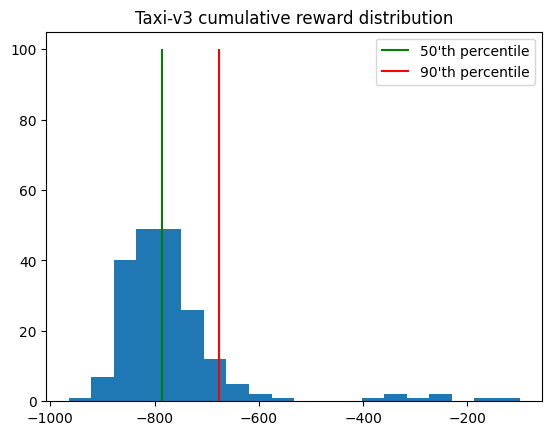

In [25]:
# посмотрим на распределение вознаграждения у случайной стратегии
import matplotlib.pyplot as plt
%matplotlib inline

num_episodes = 200
sample_cumulative_rewards = [generate_episode(env, policy, episode_length=1000)[-1] for _ in range(num_episodes)]

plt.hist(sample_cumulative_rewards, bins=20)
plt.vlines([np.percentile(sample_cumulative_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_cumulative_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.title("Taxi-v3 cumulative reward distribution")
plt.legend()

### Реализация метода crossentropy  

Наша задача - выделить лучшие действия и состояния, т.е. такие, при которых было лучшее вознаграждение:

In [26]:
def select_elites(states_batch, actions_batch, cumul_rewards_batch, percentile=50):
    """
      Выбирает состояния и действия с заданным перцентилем (rewards >= percentile)
      :param states_batch: list of lists of states, states_batch[episode_i][t]
      :param actions_batch: list of lists of actions, actions_batch[episode_i][t]
      :param cumul_rewards_batch: list of cumul rewards, cumul_rewards_batch[episode_i]
      :returns: elite_states, elite_actions - одномерные
      списки состояния и действия, выбранных сессий
    """

    # нужно найти порог вознаграждения по процентилю
    # cumul_reward_threshold =
    ####### Здесь ваш код ########
    #raise NotImplementedError
    cumul_reward_50_perc = np.percentile(cumul_rewards_batch, percentile)
    idxes = np.where(cumul_rewards_batch >= cumul_reward_50_perc)[0]
    ##############################

    # в соответствии с найденным порогом - отобрать
    # подходящие состояния и действия
    # elite_states =
    # elite_actions =
    ####### Здесь ваш код ########
    elite_states = [state for indx in idxes for state in states_batch[indx]]
    elite_actions = [action for indx in idxes for action in actions_batch[indx]]
    #raise NotImplementedError
    ##############################

    return elite_states, elite_actions

In [27]:
states_batch = [
    [1, 2, 3],     # game1
    [4, 2, 0, 2],  # game2
    [3, 1],        # game3
]

actions_batch = [
    [0, 2, 4],     # game1
    [3, 2, 0, 1],  # game2
    [3, 3],        # game3
]
cumul_rewards_batch = [
    3,  # game1
    4,  # game2
    5,  # game3
]

test_result_0 = select_elites(states_batch, actions_batch, cumul_rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, cumul_rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, cumul_rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, cumul_rewards_batch, percentile=100)

assert np.all(
    test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) \
       and np.all(
    test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]), \
    "Для процентиля 0 необходимо выбрать все состояния " \
    "и действия в хронологическом порядке"
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1])\
   and np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3]), \
    "Для процентиля 30 необходимо выбрать " \
    "состояния/действия из [3:]"
assert np.all(test_result_90[0] == [3, 1]) and \
       np.all(test_result_90[1] == [3, 3]), \
    "Для процентиля 90 необходимо выбрать состояния " \
    "действия одной игры"
assert np.all(test_result_100[0] == [3, 1]) and \
       np.all(test_result_100[1] == [3, 3]), \
    "Проверьте использование знаков: >=,  >. " \
    "Также проверьте расчет процентиля"
print("Тесты пройдены!")


Тесты пройдены!


Теперь мы хотим написать обновляющуюся стратегию:

In [28]:
def get_new_policy_table(elite_states, elite_actions):
    """
    Новой стратегией будет:
    policy[s_i,a_i] ~ #[вхождения  si/ai в лучшие states/actions]

    Не забудьте про нормализацию состояний.
    Если какое-то состояние не было посещено,
    то используйте равномерное распределение 1./n_actions

    :param elite_states:  список состояний
    :param elite_actions: список действий
    """
    new_policy_table = np.zeros([n_states, n_actions])
    for state, action in zip(elite_states, elite_actions):
        # обновляем стратегию - нормируем новые частоты
        # действий и не забываем про непосещенные состояния
        # new_policy[state][action] =
        ####### Здесь ваш код ########
        new_policy_table[state][action] += 1
        #raise NotImplementedError

    row_sums = new_policy_table.sum(axis=1, keepdims=True)
    zero_idxes = row_sums == 0
    row_sums[zero_idxes.reshape(-1)] = 1
    new_policy_table[zero_idxes.reshape(-1)] = np.full(n_actions, 1/n_actions)
    new_policy_table = new_policy_table / row_sums
    #raise NotImplementedError
    ##############################

    return new_policy_table

In [29]:
elite_states, elite_actions = (
    [1, 2, 3, 4, 2, 0, 2, 3, 1],
    [0, 2, 4, 3, 2, 0, 1, 3, 3])

new_policy_table = get_new_policy_table(elite_states, elite_actions)

assert np.isfinite(
    new_policy_table).all(), "Стратегия не должна содержать " \
                       "NaNs или +-inf. Проверьте " \
                       "деление на ноль. "
assert np.all(
    new_policy_table >= 0), "Стратегия не должна содержать " \
                      "отрицательных вероятностей "
assert np.allclose(new_policy_table.sum(axis=-1),
                   1), "Суммарная\ вероятность действий"\
                       "для состояния должна равняться 1"
reference_answer = np.array([
    [1., 0., 0., 0., 0.],
    [0.5, 0., 0., 0.5, 0.],
    [0., 0.33333333, 0.66666667, 0., 0.],
    [0., 0., 0., 0.5, 0.5]])
assert np.allclose(new_policy_table[:4, :5], reference_answer)
print("Тесты пройдены!")

Тесты пройдены!


### Цикл обучения

Визуализириуем наш процесс обучения и также будем измерять распределение получаемых за сессию вознаграждений

In [30]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Удобная функция, для визуализации результатов.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
               [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

In [31]:
class PolicyWithTable:
  def __init__(self, policy_table, learning_rate):
    self.policy_table = policy_table
    self.n_states = policy_table.shape[0]
    self.n_actions = policy_table.shape[1]
    self.learning_rate = learning_rate

  def sample(self, state: int):
    action_distribution = self.policy_table[state]
    posible_actions = np.arange(self.n_actions)
    action = np.random.choice(posible_actions, p=action_distribution)
    return action

  def fit(self, elite_states, elite_actions):
    new_policy_table = get_new_policy_table(elite_states, elite_actions)
    self.policy_table = self.learning_rate * new_policy_table + (1 - self.learning_rate) * policy_table


In [32]:
# инициализируем таблицу & инициализируем стратегию
learning_rate = 0.9 # то как быстро стратегия будет обновляться
num_episodes = 500  # количество сессий для сэмплирования
percentile = 70  # перцентиль
episode_length = 1000

# инициализируем стратегию(агента, политику)
policy_table = get_random_policy_table(n_states, n_actions)
policy = PolicyWithTable(policy_table, learning_rate)
policy.sample(env.reset()) # проверка генерации действия

np.int64(4)

In [33]:
def train_policy(policy, env, iterations=100, episode_length=1000):
  log = []

  for i in range(iterations):
      # генерируем num_episodes эпизодов(взаимодействуем со средой)
      ####### Здесь ваш код ########
      #raise NotImplementedError
      episodes = [generate_episode(env, policy, episode_length=episode_length) for _ in range(num_episodes)]
      ##############################

      states_batch, actions_batch, cumul_rewards_batch = zip(*episodes)
      # отбираем лучшие действия и состояния(формируем датасет)
      # elite_states, elite_actions =
      ####### Здесь ваш код ########
      #raise NotImplementedError
      elite_states, elite_actions = select_elites(states_batch, actions_batch, cumul_rewards_batch, percentile=percentile)
      ##############################

      # (обновляем стратегию)
      ####### Здесь ваш код ########
      #raise NotImplementedError
      policy.fit(elite_states, elite_actions)
      ##############################

      # выводим информацию об обучении(логгируем)
      show_progress(cumul_rewards_batch, log, percentile)

mean reward = -45.304, threshold=-1.000


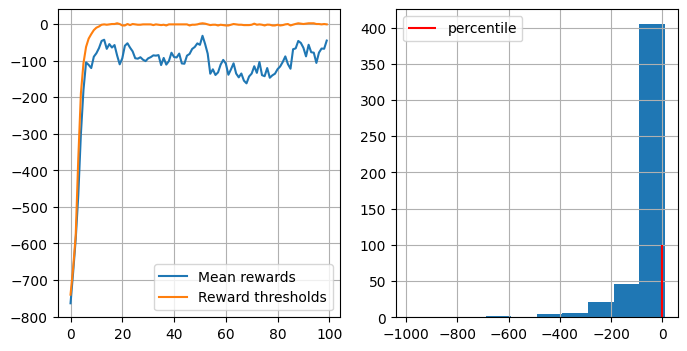

In [34]:
train_policy(policy, env, iterations=100, episode_length=episode_length)

### Посмотрим на результаты
Задача такси быстро сходится, начиная с вознаграждения -800 к почти оптимальному значению, а потом опять падает до -50/-100. Это вызвано случайностью в самом окружении $-$ случайное начальное состояние пассажира и такси, в начале каждого эпизода.

В случае если алгоритм CEM не сможет научиться тому, как решить задачу из какого-то стартового положения, он просто отбросит этот эпизод, т.к. не будет сессий, которые переведут этот эпизод в топ лучших.

Для решения этой проблемы можно уменьшить threshold (порог лучших состояний) или изменить способ оценки стратегии, используя новую стратегию, полученную из каждого начального состояния и действия (теоретически правильный способ).

## 3. Deep CEM

В данной части мы рассмотрим применение CEM вместе с нейронной сетью.
Будем обучать многослойную нейронную сеть для решения простой задачи с непрерывным пространством действий.

<img src="https://camo.githubusercontent.com/8f39c7f54a7798e7f80c9ec5c0bb610696e5c5b7/68747470733a2f2f7469702e64756b652e6564752f696e646570656e64656e745f6c6561726e696e672f677265656b2f6c6573736f6e2f64696767696e675f6465657065725f66696e616c2e6a7067">

Будем тестировать нашего нового агента на известной задаче маятника с непрерывным пространством состояний.
https://www.gymlibrary.dev/environments/classic_control/cart_pole/

In [35]:
env = gym.make("CartPole-v0")

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print(f"состояний: {state_dim} действий: {n_actions}")

состояний: 4 действий: 2


/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1` with the environment ID `CartPole-v1`.
  logger.warn(


### Стратегия с нейронной сетью

Попробуем заменить метод обновления вероятностей на нейронную сеть.
Будем пользоваться упрощенной реализацией нейронной сети из пакета Scikit-learn.
Нам потребуется:
* agent.partial_fit(states, actions) - делает один проход обучения по данным. Максимизирует вероятность :actions: из :states:
* agent.predict_proba(states) - предсказыает вероятность каждого из действий, в виде матрицы размера [len(states), n_actions]

In [36]:
from sklearn.neural_network import MLPClassifier

neural_network = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation='tanh',
)

# инициализируем агента под заданное пространство состояний и действий
# partial_fit(X, y, classes)
neural_network.partial_fit([env.reset()] * n_actions, range(n_actions), range(n_actions))

MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [37]:
class PolicyWithNN:
  def __init__(self, neural_network):
    self.neural_network = neural_network

  def sample(self, state):
    action_distribution = self.neural_network.predict_proba([state])[0]
    posible_actions = np.arange(action_distribution.shape[0])
    action = np.random.choice(posible_actions, p=action_distribution)
    return action

  def fit(self, elite_states, elite_actions):
    self.neural_network.fit(elite_states, elite_actions)

In [38]:
policy = PolicyWithNN(neural_network)
policy.sample(env.reset())

np.int64(1)

mean reward = 196.162, threshold=200.000


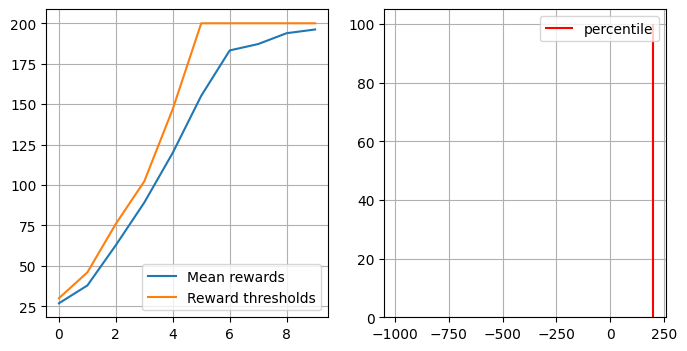

In [39]:
train_policy(policy, env, iterations=10)

In [40]:
env.close()

In [41]:
env = gym.make("CartPole-v0")
env = gym.wrappers.Monitor(env, "./video", force=True)

generate_episode(env, policy, episode_length=100)

env.close()
show_video()

env.close()

/usr/local/lib/python3.11/dist-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1` with the environment ID `CartPole-v1`.
  logger.warn(


## Summary

### Gym
Gym имеет интерфейс(API) из 4х функций
* reset: state = env.reset()
* step: state, reward, done, info = env.step()
* render: state, reward, done, info = env.render()
* close: env.close()


#### CEM(Cross Entropy Method)
Основной цикл обучения стратегии
* Взаимодействие со средой: generate_episode(env, policy)
* Формирование датасета(модификация): select_elites
* Обновление стратегии: policy.fit()

Алгоритм SEM(на основе таблички)
* Сэмплируем эпизоды generate_episode()
* Выбираем элитные траектории select_elites()
* Обновляем табличку для стратегии

### DeepCEM(Deep Cross Entropy Method)
Алгоритм DeepSEM(на основе нейросети)
* Сэмплируем эпизоды generate_episode()
* Выбираем элитные траектории select_elites()
* Обновляем нейросеть у стратегии